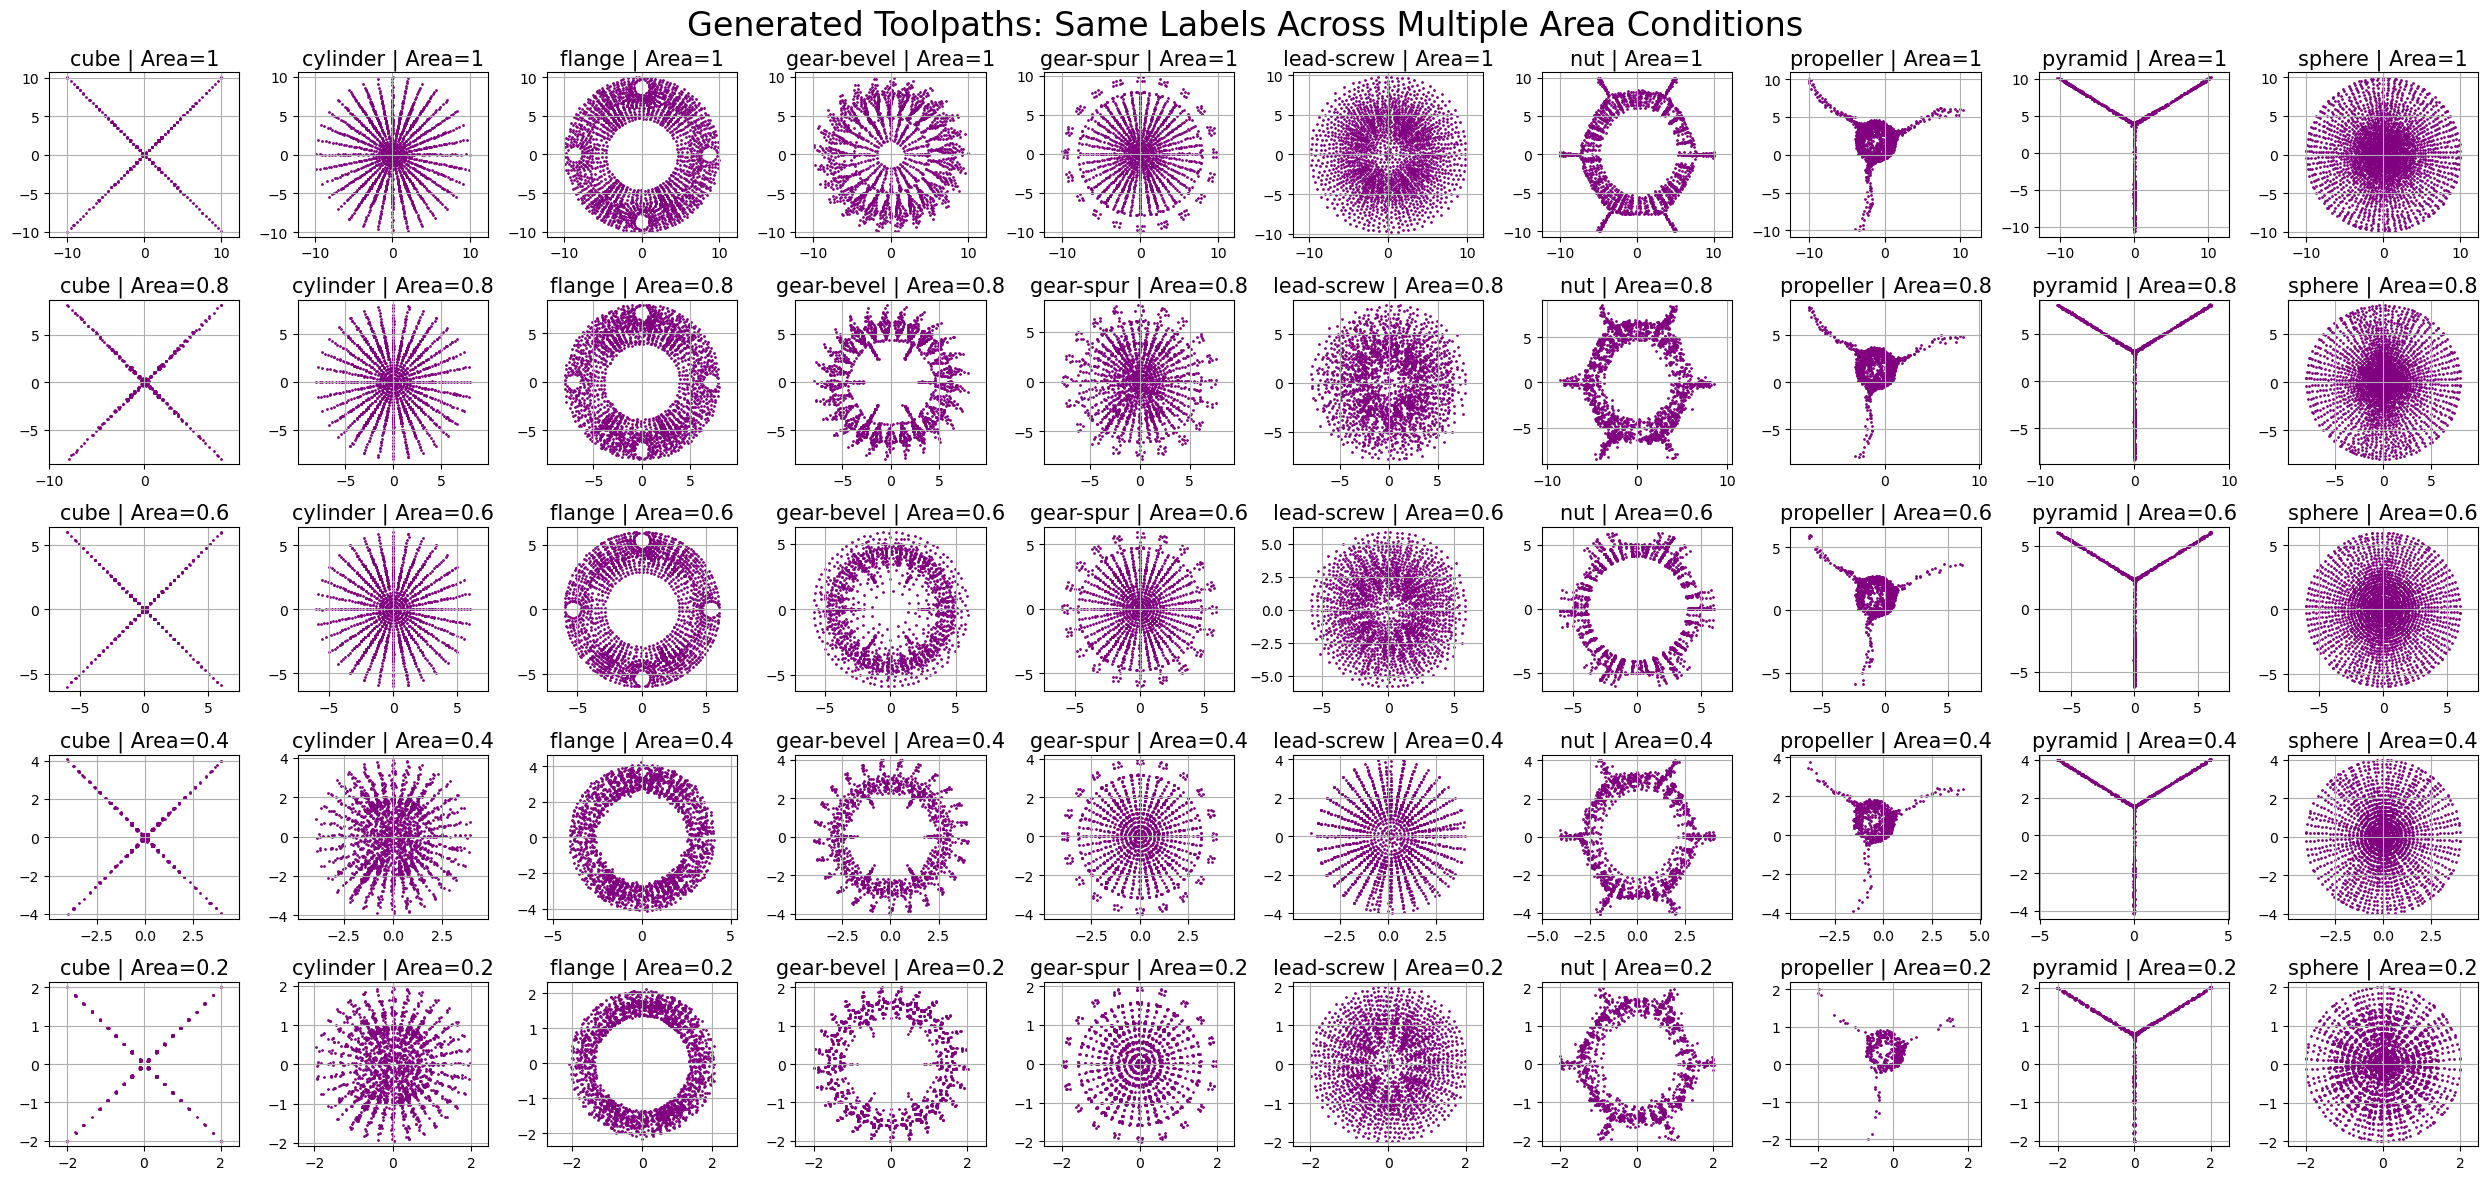

In [16]:
# =====================================================
# Inference: C-WGAN-GP + Gaussian Penalty (Conditional)
# One Sample per Class (2x5 Grid)
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\\ModelGANV1_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\ModelAEV4\cae_fold3.pt")

# =====================================================
# Hyperparameters (must match training)
# =====================================================
latent_size = 512
point_size = 2900        # number of 2D points per layer (adjust if different)
num_classes = 10         # adjust to your label_map size
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

def subsample_and_pad(points, keep_ratio, target_points=2900):
    N = points.shape[0]
    k = max(1, int(N * keep_ratio))

    idx = torch.randperm(N, device=points.device)[:k]
    kept = points[idx]

    if k < target_points:
        pad = torch.zeros(target_points - k, 2, device=points.device)
        kept = torch.cat([kept, pad], dim=0)

    return kept
# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Load Models
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# Generate Five Areas × All Classes
# =====================================================
with torch.no_grad():
    area_values = [1, 0.8, 0.6, 0.4, 0.2]
    num_areas = len(area_values)

    # Noise: one per (area, class)
    z_noise = torch.randn(num_areas * num_classes, latent_size).to(device)

    # Labels repeated for each area
    labels = torch.arange(num_classes).repeat(num_areas)
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float().to(device)

    # Areas stacked row-wise
    areas_dummy = torch.tensor(
        [[a] for a in area_values for _ in range(num_classes)],
        dtype=torch.float32
    ).to(device)

    # Conditions
    conds = torch.cat([areas_dummy, labels_onehot], dim=1)

    # Generator → latent
    fake_latents = G(z_noise, conds)

    # Decode → 2D points
    decoded = cae(fake_latents, conds)          # (B, P, 2)
    decoded_scaled = decoded.clone()
    # --------------------------------------------------
    # Force propeller (label 7) to reuse area=1 geometry
    # --------------------------------------------------
    # ===== ONLY FOR PROPELLER (label = 7) =====
    prop_label = 7
    prop_idxs = torch.where(labels == prop_label)[0]
    
    # reference propeller at area = 1 (FIRST ROW)
    ref_idx = prop_idxs[0]
    prop_ref = decoded[ref_idx].clone()   # (2900, 2)
    
    for idx in prop_idxs:
        area_val = conds[idx, 0].item()   # 1.0, 0.8, 0.6, ...
    
        scaled = prop_ref * area_val
        scaled = subsample_and_pad(scaled, area_val, point_size)
    
        decoded_scaled[idx] = scaled * 10.0
    # ===== END PROPELLER ONLY =====
    for i in range(decoded.shape[0]):
        if labels[i].item() != 7:
            decoded_scaled[i] = decoded[i] * conds[i, 0] * 10.0

# =====================================================
# Plot Results (5 rows × 10 columns)
# =====================================================
rows, cols = num_areas, num_classes
fig, axs = plt.subplots(rows, cols, figsize=(25, 12))

# -----------------------------------------------------
# Normalized area min/max per class (from your table)
# -----------------------------------------------------
area_range = {
    0: (0, 1.0000),  # cube
    1: (0, 1.0000),  # cylinder
    2: (0, 1.0000),  # flange
    3: (0, 1.0000),  # gear_bevel
    4: (0, 1.0000),  # gear_spur
    5: (0, 1.0000),  # lead_screw
    6: (0, 1.0000),  # nut
    7: (0, 1.0000),  # propeller
    8: (0, 1.0000),  # pyramid
    9: (0, 1.0000),  # sphere
}
class_names = {
    0: "cube",
    1: "cylinder",
    2: "flange",
    3: "gear-bevel",
    4: "gear-spur",
    5: "lead-screw",
    6: "nut",
    7: "propeller",
    8: "pyramid",
    9: "sphere",
}


for r in range(rows):
    for c in range(cols):
        idx = r * cols + c
        min_a, max_a = area_range[c]
        area_val = area_values[r]    
        color = "purple" if (min_a <= area_val <= max_a) else "green"
        pts = decoded_scaled[idx].cpu().numpy()

        axs[r, c].scatter(
            pts[:, 0],
            pts[:, 1],
            s=1,
            color=color
        )
        axs[r, c].set_title(
            f"{class_names[c]} | Area={area_values[r]}",
            fontsize=15
        )
        axs[r, c].axis("equal")
        #axs[r, c].set_xlim(-1.2, 1.2)
        #axs[r, c].set_ylim(-1.2, 1.2)
        axs[r, c].grid(True)

plt.suptitle(
    "Generated Toolpaths: Same Labels Across Multiple Area Conditions",
    fontsize=24
)
#plt.subplots_adjust(top=0.85)

plt.tight_layout()

plt.savefig("generated_toolpaths_areas.png", dpi=600, bbox_inches="tight")

plt.show() 

In [3]:
import numpy as np
import pandas as pd

# =====================================================
# Load dataset
# =====================================================
dataset = np.load(
    r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\DatasetRV1\gcode_layers_V1.npy",
    allow_pickle=True
).item()

areas_norm = dataset["areas_norm"]     # (N, L)
labels_int = dataset["labels"]         # (N,)
label_map = dataset["label_map"]       # name -> int

# reverse label map: int -> name
idx_to_label = {v: k for k, v in label_map.items()}

# =====================================================
# Collect stats per label
# =====================================================
rows = []

for label_int, label_name in idx_to_label.items():
    idxs = np.where(labels_int == label_int)[0]

    # flatten all layers for this label
    label_areas = np.concatenate([areas_norm[i] for i in idxs])

    rows.append({
        "label_id": label_int,
        "label_name": label_name,
        "min_area_norm": float(label_areas.min()),
        "max_area_norm": float(label_areas.max()),
        "mean_area_norm": float(label_areas.mean()),
        "num_layers": len(label_areas)
    })

# =====================================================
# Print table
# =====================================================
df = pd.DataFrame(rows).sort_values("label_id")
pd.set_option("display.float_format", "{:.4f}".format)

print(df.to_string(index=False))


 label_id label_name  min_area_norm  max_area_norm  mean_area_norm  num_layers
        0       cube         0.0000         1.0000          0.4138         590
        1   cylinder         0.0000         1.0000          0.4724         590
        2     flange         0.0000         1.0000          0.2951         590
        3 gear_bevel         0.0000         1.0000          0.3771         590
        4  gear_spur         0.0000         1.0000          0.4623         590
        5 lead_screw         0.0000         1.0000          0.5362         590
        6        nut         0.0000         1.0000          0.5761         590
        7  propeller         0.0000         1.0000          0.3753         590
        8    pyramid         0.0000         1.0000          0.2237         590
        9     sphere         0.0000         1.0000          0.3536         590


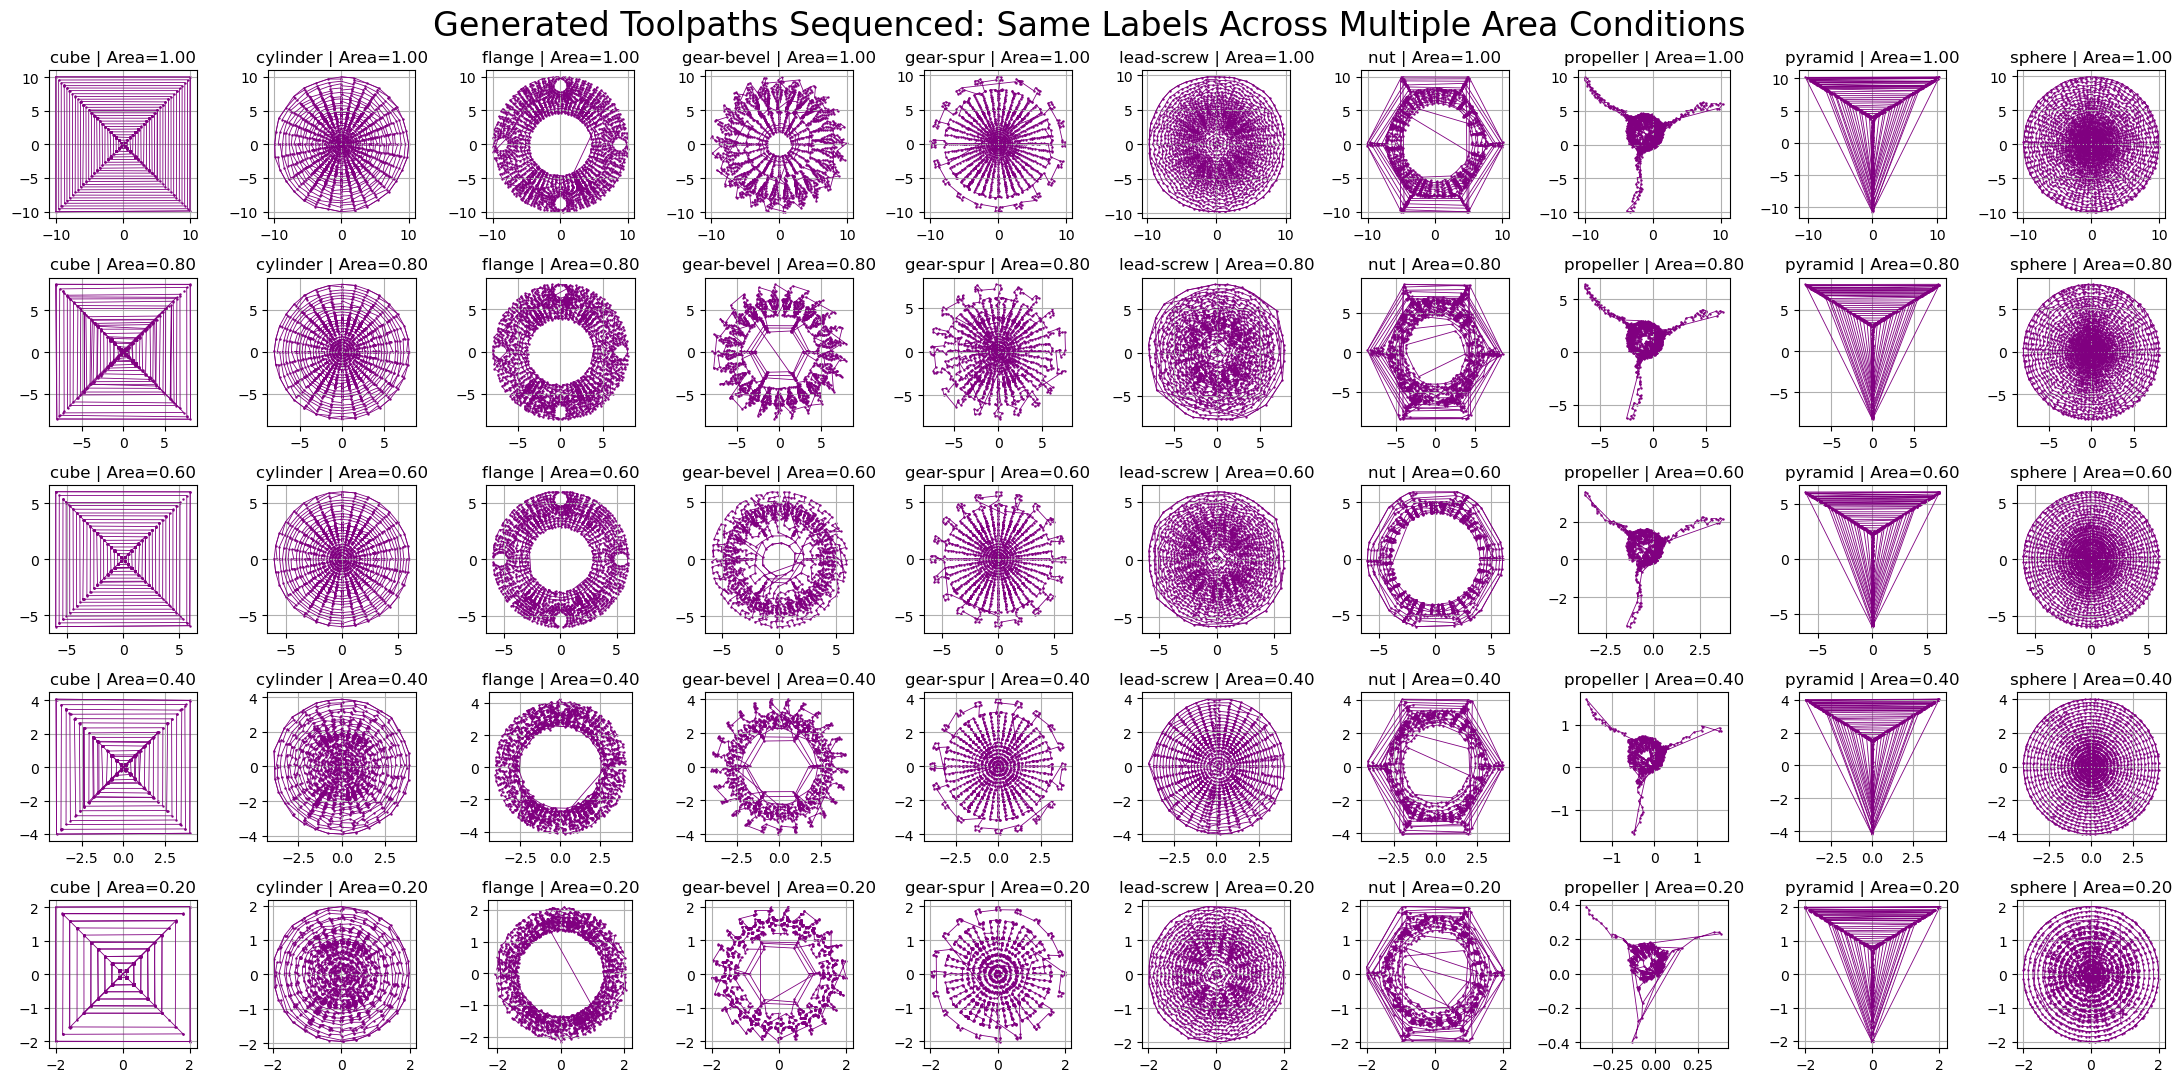

In [24]:
# =====================================================
# FIXED FULL CODE (ENC + DEC RESTORED)
# Grid Layout:
#   Columns = 10 Shape Classes
#   Rows    = Area Values
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.spatial import ConvexHull, distance

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\\ModelGANV1_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\ModelAEV4\cae_fold3.pt")

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2900
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Class Names
# =====================================================
class_names = {
    0: "cube", 1: "cylinder", 2: "flange", 3: "gear-bevel",
    4: "gear-spur", 5: "lead-screw", 6: "nut",
    7: "propeller", 8: "pyramid", 9: "sphere",
}

# =====================================================
# Area Ranges
# =====================================================
area_range = {i: (0, 1.0) for i in range(10)}

def subsample_and_pad_np(points, keep_ratio, target_points=2900):
    N = points.shape[0]
    k = max(1, int(N * keep_ratio))
    idx = np.random.choice(N, k, replace=False)
    kept = points[idx]
    if k < target_points:
        pad = np.zeros((target_points - k, 2))
        kept = np.vstack([kept, pad])
    return kept

# =====================================================
# MODELS (ENC + DEC EXACT MATCH)
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        return self.dec(torch.cat([z, cond], dim=1)).view(-1, self.P, 2)

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# LOAD MODELS
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# GEOMETRY UTILITIES (UNCHANGED)
# =====================================================
def multilayer_bands_origin(points, band_width=0.05, max_layers=3):
    d = np.linalg.norm(points, axis=1)
    r0 = d.min()
    loops, band_idx = [], set()

    for k in range(max_layers):
        mask = (d >= r0 + k * band_width) & (d <= r0 + (k + 1) * band_width)
        pts = points[mask]

        if len(pts) > 3:
            ang = np.arctan2(pts[:, 1], pts[:, 0])
            order = np.argsort(ang)
            loops.append(np.vstack([pts[order], pts[order][0]]))
            band_idx.update(np.where(mask)[0])

    return loops, points, band_idx, r0


def nested_loops_with_hull(points, band_idx, r_band, step=0.05):
    d = np.linalg.norm(points, axis=1)
    mask = np.ones(len(points), bool)
    mask[list(band_idx)] = False

    pts, d = points[mask], d[mask]
    layers = []

    if len(pts) > 3:
        try:
            hull = ConvexHull(pts)
            h = pts[hull.vertices]
            layers.append(np.vstack([h, h[0]]))
        except:
            pass

    r = d.max()

    while r > r_band:
        shell = pts[(d <= r) & (d > r - step)]

        if len(shell) > 3:
            ang = np.arctan2(shell[:, 1], shell[:, 0])
            order = np.argsort(ang)
            layers.append(np.vstack([shell[order], shell[order][0]]))

        r -= step

    return layers

def nearest_neighbor_path(points):
    idx = list(range(len(points)))
    path = [idx.pop(0)]
    while idx:
        last = path[-1]
        d = distance.cdist([points[last]], points[idx])[0]
        j = idx[np.argmin(d)]
        path.append(j)
        idx.remove(j)
    return points[path]

# =====================================================
# AREA ROWS
# =====================================================
area_values = [1, 0.8, 0.6, 0.4, 0.2]
rows, cols = len(area_values), num_classes
fig, axs = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))

nested_classes = {0,1,5,6,8,9}
nn_classes = {2,3,4,7}

# 🔒 FIXED PROP LATENT + GEOMETRY
z_propeller_fixed = torch.randn(1, latent_size).to(device)
propeller_ref_pts = None

# =====================================================
# INFERENCE + PLOT
# =====================================================
for r_idx, area_val in enumerate(area_values):
    z = torch.randn(num_classes, latent_size).to(device)
    z[7] = z_propeller_fixed
    labels = torch.arange(num_classes)
    onehot = F.one_hot(labels, num_classes).float().to(device)
    areas = torch.full((num_classes, 1), area_val, device=device)
    cond = torch.cat([areas, onehot], dim=1)

    with torch.no_grad():
        decoded = cae(G(z, cond), cond)

    decoded = decoded.cpu().numpy()

    if area_val == 1 and propeller_ref_pts is None:
        propeller_ref_pts = decoded[7].copy()

    for c_idx in range(num_classes):
        ax = axs[r_idx, c_idx]
        pts = np.round(decoded[c_idx], 3)

        if c_idx == 7:
            pts = propeller_ref_pts * area_val
            pts = subsample_and_pad_np(pts, area_val, point_size)
        else:
            pts = np.unique(pts, axis=0)

        scale_mm = area_val * 10.0
        color = "purple"

        loops, all_pts, band_idx, r_band = multilayer_bands_origin(pts)

        ax.scatter(all_pts[:,0]*scale_mm, all_pts[:,1]*scale_mm, s=0.5, color=color)

        for loop in loops:
            ax.plot(loop[:,0]*scale_mm, loop[:,1]*scale_mm, color=color, lw=0.6)

        if c_idx in nested_classes:
            for layer in nested_loops_with_hull(all_pts, band_idx, r_band):
                ax.plot(layer[:,0]*scale_mm, layer[:,1]*scale_mm, color=color, lw=0.6)

        if c_idx in nn_classes:
            path = nearest_neighbor_path(all_pts)
            ax.plot(path[:,0]*scale_mm, path[:,1]*scale_mm, color=color, lw=0.6)

        ax.set_title(f"{class_names[c_idx]} | Area={area_val:.2f}", fontsize=12)
        ax.set_aspect("equal")
        ax.grid(True)

plt.suptitle("Generated Toolpaths Sequenced: Same Labels Across Multiple Area Conditions", fontsize=24)
plt.tight_layout()
plt.savefig("generated_toolpaths_Sequenced_areas_10_6.png", dpi=600, bbox_inches="tight")
plt.show()


✅ Showing 10 layers (areas_norm = 1, scaled ×10)


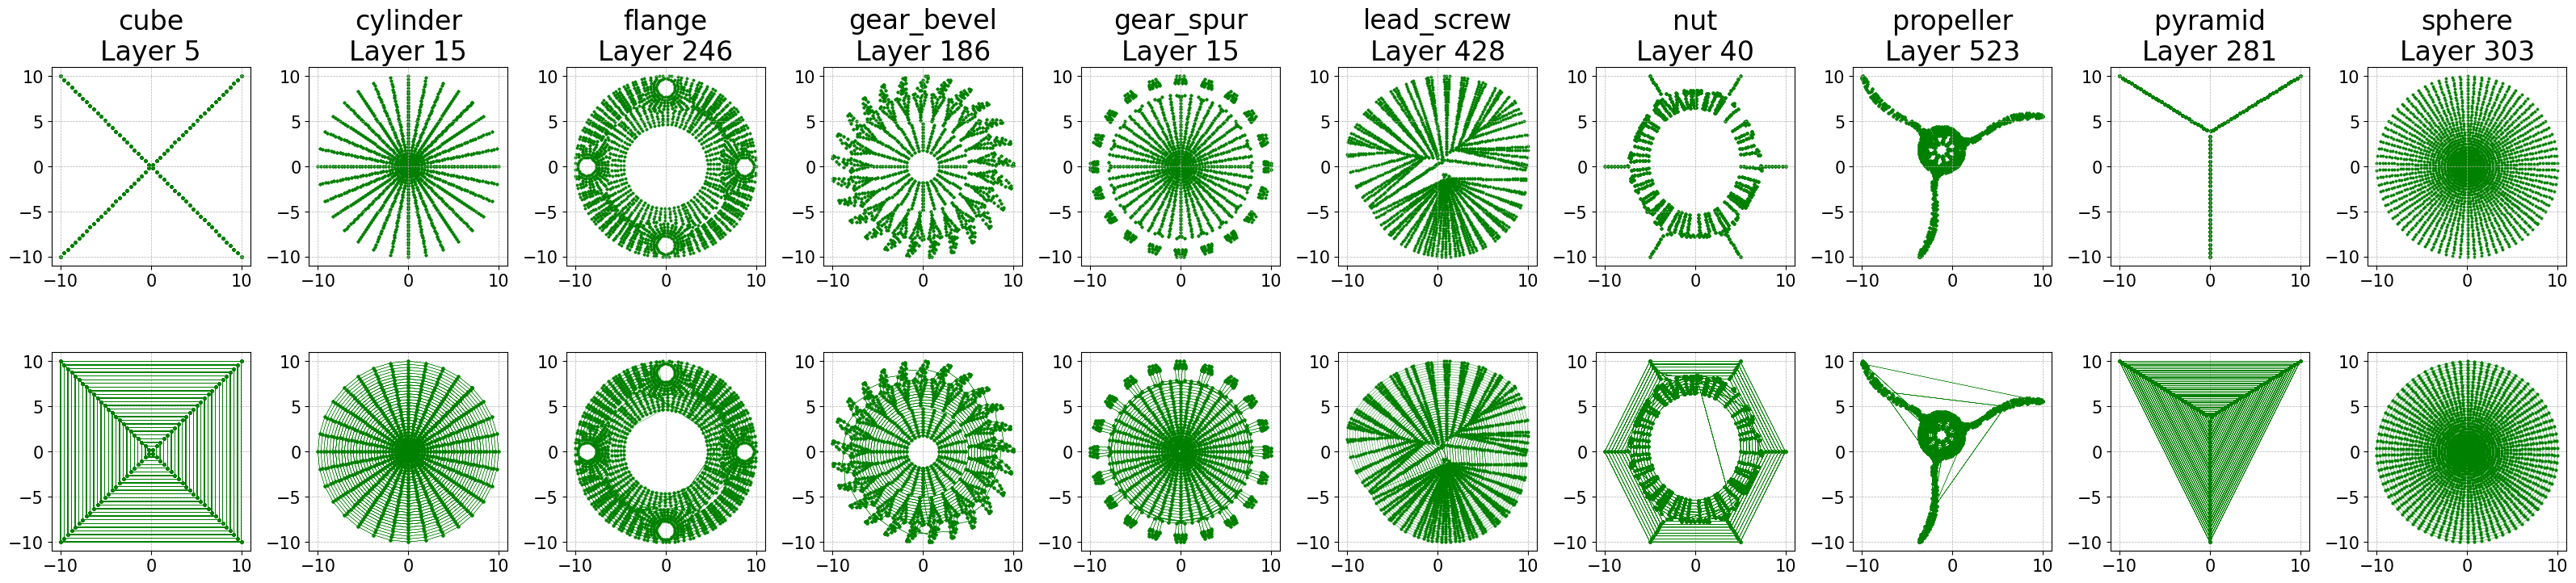

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# === Load dataset ===
npy_path = r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\DatasetRV1\gcode_layers_V1.npy"
loaded = np.load(npy_path, allow_pickle=True).item()

X = loaded["data"]
y = loaded["labels"]
areas_norm = loaded["areas_norm"]
label_map = loaded["label_map"]

name_map = {v: k for k, v in label_map.items()}
num_labels = len(label_map)

# === Select ONE layer per label where areas_norm == 1 ===
selected = {}

for file_idx, file in enumerate(X):
    label = y[file_idx]
    if label in selected:
        continue

    for layer_idx, layer in enumerate(file):
        if areas_norm[file_idx, layer_idx] != 1:
            continue

        if not np.any(layer):
            continue

        points = layer[~np.all(layer == 0, axis=1)]
        if len(points) < 3:
            continue

        # Scale ×10
        points = points * 10.0

        selected[label] = (points, name_map[label], layer_idx + 1)
        break

    if len(selected) == num_labels:
        break

print(f"✅ Showing {len(selected)} layers (areas_norm = 1, scaled ×10)")

# === Plot: 2 × 10 grid ===
fig, axs = plt.subplots(2, num_labels, figsize=(32, 8))

for col, label in enumerate(sorted(selected.keys())):
    pts, shape, layer_id = selected[label]

    for row in [0, 1]:
        ax = axs[row, col]
        ax.set_aspect("equal")

        # IMPORTANT: keep ticks so grid is visible
        ax.tick_params(labelsize=15)

        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Row 1: Scatter
    axs[0, col].scatter(
        pts[:, 0], pts[:, 1],
        s=6, color="green", linewidth=0.3
    )
    axs[0, col].set_title(f"{shape}\nLayer {layer_id}", fontsize=24)

    # Row 2: Connected
    axs[1, col].plot(
        pts[:, 0], pts[:, 1],
        "-o", color="green", markersize=2, linewidth=0.3
    )

plt.tight_layout()

plt.savefig("Original Points and toolpath.png", dpi=600, bbox_inches="tight")

plt.show()
